# cuVS CAGRA build + concurrent search benchmark

Sweeps `(size, dim, search_concurrency)` and measures build time, recall@k, search wall, and effective QPS.

- METRIC = squared L2; params live in `index_size_params.yaml`.
- `sc=1` runs the safe Python sequential path.
- `sc>1` with `USE_CUVS_PROCESS_CONCURRENCY=True` shells out to the C++ client (`cuvs_cagra_client`) which does `sc` concurrent in-flight `cagra.search` calls into a single persistent kernel — same pattern as `cuvs-bench`.

## How a search request flows

```text
┌─ Notebook (Python) ──────────────────────────────────────────────┐
│  build CAGRA → save index → write queries.bin → spawn child      │
└──────────────────────────────│───────────────────────────────────┘
                               ▼
┌─ C++ binary (one process, one CUDA context) ────────────────────┐
│  cuvsCagraDeserialize(index)                                    │
│  search_params.persistent = true                                │
│  warmup → launches persistent kernel (stays resident)           │
│                                                                 │
│      std::async × c                                             │
│      ┌───────────┐                                              │
│      │ thread 0  │ ──┐                                          │
│      │ thread 1  │   │  drop 1-query searches into the          │
│      │   ...     │   ├─►kernel queue (~hundreds in flight)      │
│      │ thread c-1│ ──┘                                          │
│      └───────────┘                                              │
└──────────────────────────────│──────────────────────────────────┘
                               ▼
┌─ Persistent CAGRA kernel (GPU) ──────────────────────────────────┐
│  queue: [q0][q1][q2]…[qN]   ← always full while threads submit   │
│  CTA 0: q0 │ CTA 1: q1 │ CTA 2: q2 │ … │ CTA n: qn               │
│  each CTA traverses the graph and writes top-k to n_dev/d_dev    │
└──────────────────────────────│───────────────────────────────────┘
                               ▼
┌─ C++ binary ────────────────────────────────────────────────────┐
│  cudaMemcpy n_dev → host  → write neighbors.bin + meta.json     │
└──────────────────────────────│──────────────────────────────────┘
                               ▼
┌─ Notebook ──────────────────────────────────────────────────────┐
│  np.fromfile → reshape → recall vs ground truth → QPS → plot    │
└─────────────────────────────────────────────────────────────────┘
```

In [17]:
import os
import struct
import time

import cupy  # noqa: F401
import numpy as np
import pandas as pd
import yaml
from cuvs.neighbors import brute_force  # noqa: F401
from tqdm import tqdm

SCRIPT_DIR = os.path.abspath(".")
DATASET_PATH = os.environ.get("CUVS_DATASET_PATH", "/raid/scripts/datasets/miracl-5M")
BASE_FILE = f"{DATASET_PATH}/base.fbin"
QUERY_FILE = f"{DATASET_PATH}/query.fbin"

with open(os.path.join(SCRIPT_DIR, "index_size_params.yaml")) as f:
    PARAMS = yaml.safe_load(f)
INDEX_TYPE = "cagra"   # "cagra" | "ivf_pq"
CUVS_BUILD_ALGO = str(PARAMS.get("cagra", PARAMS.get("cuvs", {})).get("build_algo", "nn_descent"))

# Benchmark sweeps.
SIZES = [1_000_000]
BENCHMARK_DIMS = [2048]
SEARCH_CONCURRENCY = [1, 64]   # in-flight searches per call (c). int or list.
SEARCH_BATCH_SIZES = [64,1] # queries per cagra.search call (bs). int or list.
PROCESS_SEARCH_ITERS = 2        # timed iters averaged in the C++ client

# C++ client (one persistent kernel + std::async) when c > 1; else safe sequential Python.
USE_CUVS_PROCESS_CONCURRENCY = True

K = 10
METRIC = "sqeuclidean"

def _aslist(x):
    return [int(v) for v in (x if isinstance(x, (list, tuple)) else [x])]

_SEARCH_C_LEVELS = _aslist(SEARCH_CONCURRENCY)
_SEARCH_BS_LEVELS = _aslist(SEARCH_BATCH_SIZES)
print(f"index={INDEX_TYPE} | c={_SEARCH_C_LEVELS} | bs={_SEARCH_BS_LEVELS} | cagra_build_algo={CUVS_BUILD_ALGO}")

c=[1, 64] | bs=[64, 1] | build_algo=ivf_pq


In [18]:
def load_fbin(path, max_rows=None):
    """Load .fbin file (header: n_vectors, dim as uint32; data: float32)."""
    with open(path, "rb") as f:
        n, dim = struct.unpack("<II", f.read(8))
        if max_rows is not None:
            n = min(n, max_rows)
        data = np.fromfile(f, dtype=np.float32, count=n * dim)
    return data.reshape(n, dim).astype(np.float32)

def get_dataset_shape(path):
    """Read (n_vectors, dim) from fbin header without loading data."""
    with open(path, "rb") as f:
        n, dim = struct.unpack("<II", f.read(8))
    return n, dim

n_base, dim = get_dataset_shape(BASE_FILE)
n_queries, _ = get_dataset_shape(QUERY_FILE)
print(f"Base: {n_base:,} x {dim}, Queries: {n_queries:,}")

# Trim sizes to available data
SIZES = [s for s in SIZES if s <= n_base]
if not SIZES:
    SIZES = [min(10_000, n_base), n_base]
print(f"Benchmark sizes: {SIZES}")

# Dimension sweep (BENCHMARK_DIMS from config cell; None / [] => full dim only)
if BENCHMARK_DIMS is None or BENCHMARK_DIMS == []:
    BENCHMARK_DIMS = [dim]
else:
    BENCHMARK_DIMS = [int(d) for d in BENCHMARK_DIMS]
    bad = [d for d in BENCHMARK_DIMS if not (1 <= d <= dim)]
    if bad:
        raise ValueError(f"BENCHMARK_DIMS must be in [1, {dim}]; invalid: {bad}")
print(f"Benchmark dimensions: {BENCHMARK_DIMS}")

Base: 4,990,000 x 2048, Queries: 10,000
Benchmark sizes: [1000000]
Benchmark dimensions: [2048]


In [19]:
# Load base via mmap (avoids loading full 20GB into RAM when subsampling)
# Query file is small, load fully.
print("Loading base and query data...")
base_mmap = np.memmap(BASE_FILE, dtype=np.float32, mode="r", offset=8, shape=(n_base, dim))
queries = load_fbin(QUERY_FILE)

def get_base_slice(size):
    """Return base[:size] as contiguous float32 (needed for some libraries)."""
    return np.ascontiguousarray(base_mmap[:size].astype(np.float32))


def truncate_to_dim(x, d):
    """Keep the first d dimensions (columns); output is contiguous float32."""
    return np.ascontiguousarray(np.asarray(x, dtype=np.float32)[:, :d])


print(f"Base: {n_base:,} x {dim} (mmap), Queries: {queries.shape}")

Loading base and query data...


Base: 4,990,000 x 2048 (mmap), Queries: (10000, 2048)


In [20]:
def calc_recall(ann_idx, true_nn_idx):
    """Recall@K: proportion of true neighbors found."""
    ann = np.asarray(ann_idx, dtype=np.int64)
    gt = np.asarray(true_nn_idx, dtype=np.int64)
    return sum(np.intersect1d(ann[i], gt[i]).size for i in range(ann.shape[0])) / ann.size

def compute_groundtruth(base, queries, k):
    """Brute-force KNN ground truth on GPU (same METRIC as the indexed search)."""
    import gc
    import cupy as cp
    from cuvs.neighbors import brute_force

    base_gpu = cp.asarray(base.astype(np.float32))
    queries_gpu = cp.asarray(queries.astype(np.float32))
    index = brute_force.build(base_gpu, metric=METRIC)
    _, idx = brute_force.search(index, queries_gpu, k)
    if hasattr(idx, "copy_to_host"):
        idx_host = np.asarray(idx.copy_to_host(), dtype=np.int64)
    elif hasattr(idx, "get"):
        idx_host = np.asarray(idx.get(), dtype=np.int64)
    else:
        idx_host = np.asarray(cp.asarray(idx), dtype=np.int64)
    del base_gpu, queries_gpu, index, idx
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()
    return idx_host

In [21]:
def benchmark_cuvs_index(base, queries, k, search_concurrency=1, batch_size=1):
    """Build + search a cuVS index (CAGRA or IVF-PQ depending on INDEX_TYPE).

    sc>1 with USE_CUVS_PROCESS_CONCURRENCY=True spawns the master C++ client (cuvs_cagra_client),
    which fires sc concurrent in-flight searches via std::async. Otherwise runs the safe Python path.
    """
    import cupy as cp
    from cuvs.neighbors import cagra, ivf_pq

    sc = int(search_concurrency)
    bs = max(1, int(batch_size))
    queries_cpu = np.asarray(queries, dtype=np.float32)
    nq = int(queries_cpu.shape[0])
    base_gpu = cp.asarray(base)

    # Build per INDEX_TYPE.
    if INDEX_TYPE == "cagra":
        p = PARAMS["cagra"]
        itopk = int(p.get("itopk_size", 64))
        persistent = bool(p.get("persistent", False))
        t0 = time.perf_counter()
        idx = cagra.build(
            cagra.IndexParams(
                metric=METRIC,
                graph_degree=p["graph_degree"],
                intermediate_graph_degree=p["intermediate_graph_degree"],
                build_algo=CUVS_BUILD_ALGO,
            ),
            base_gpu,
        )
        t_build = time.perf_counter() - t0
        save_fn, search_params, neigh_dtype = cagra.save, cagra.SearchParams(itopk_size=itopk, persistent=persistent), cp.uint32
        cli_extra = ["--itopk-size", str(itopk), "--persistent", "1" if persistent else "0"]
    elif INDEX_TYPE == "ivf_pq":
        p = PARAMS["ivf_pq"]
        n_probes = int(p.get("n_probes", 32))
        t0 = time.perf_counter()
        idx = ivf_pq.build(ivf_pq.IndexParams(metric=METRIC, n_lists=int(p["n_lists"])), base_gpu)
        t_build = time.perf_counter() - t0
        save_fn, search_params, neigh_dtype = ivf_pq.save, ivf_pq.SearchParams(n_probes=n_probes), np.int64
        cli_extra = ["--n-probes", str(n_probes)]
    else:
        raise ValueError(f"Unknown INDEX_TYPE: {INDEX_TYPE}")

    if sc > 1 and USE_CUVS_PROCESS_CONCURRENCY:
        import json
        import subprocess
        import tempfile

        files = [tempfile.NamedTemporaryFile(prefix=f"cuvs_{n}_", suffix=s, delete=False).name
                 for n, s in [("idx", ".bin"), ("q", ".bin"), ("n", ".bin"), ("m", ".json")]]
        index_file, queries_file, neighbors_file, meta_file = files
        try:
            save_fn(index_file, idx)
            queries_cpu.tofile(queries_file)
            subprocess.run([
                os.path.join(SCRIPT_DIR, "cuvs_search_client"),
                "--algo", INDEX_TYPE,
                "--index-file", index_file,
                "--queries-file", queries_file,
                "--out-neighbors", neighbors_file,
                "--out-meta", meta_file,
                "--shape", f"{nq},{queries_cpu.shape[1]}",
                "--k", str(int(k)),
                "--c", str(sc),
                "--batch-size", str(bs),
                "--iters", str(int(PROCESS_SEARCH_ITERS)),
                *cli_extra,
            ], check=True)
            np_dtype = np.uint32 if INDEX_TYPE == "cagra" else np.int64
            neighbors = np.fromfile(neighbors_file, dtype=np_dtype).reshape(nq, k).astype(np.int64)
            with open(meta_file) as f:
                wall = float(json.load(f)["search_wall_s"])
        finally:
            for fp in files:
                if os.path.exists(fp):
                    os.remove(fp)
        total_q = nq
    else:
        # Safe sequential single-stream Python path.
        queries_gpu = cp.ascontiguousarray(cp.asarray(queries_cpu))
        neigh_gpu = cp.empty((nq, k), dtype=neigh_dtype)
        dist_gpu = cp.empty((nq, k), dtype=cp.float32)
        search_fn = cagra.search if INDEX_TYPE == "cagra" else ivf_pq.search
        search_fn(search_params, idx, queries_gpu[:bs], k, neighbors=neigh_gpu[:bs], distances=dist_gpu[:bs])
        cp.cuda.Device().synchronize()
        t0 = time.perf_counter()
        for _ in range(max(1, sc)):
            for s in range(0, nq, bs):
                e = min(s + bs, nq)
                search_fn(search_params, idx, queries_gpu[s:e], k, neighbors=neigh_gpu[s:e], distances=dist_gpu[s:e])
        cp.cuda.Device().synchronize()
        wall = time.perf_counter() - t0
        neighbors = cp.asnumpy(neigh_gpu).astype(np.int64)
        total_q = nq * max(1, sc)

    return {
        "build_time_s": t_build,
        "neighbors": neighbors,
        "search_wall_s": wall,
        "search_qps_effective": total_q / wall if wall > 0 else float("nan"),
    }

In [22]:
def benchmark_faiss_hnsw(base, queries, k):
    """FAISS CPU HNSW (single-threaded search call; FAISS uses OMP internally).
    Params from index_size_params.yaml (faiss section). METRIC_L2 = squared L2.
    """
    import faiss

    faiss.omp_set_num_threads(os.cpu_count() or 8)
    fa = PARAMS["faiss"]
    base_c = np.ascontiguousarray(base.astype(np.float32))
    queries_c = np.ascontiguousarray(queries.astype(np.float32))

    index = faiss.IndexHNSWFlat(base_c.shape[1], fa["M"], faiss.METRIC_L2)
    index.hnsw.efConstruction = fa["ef_construction"]
    index.hnsw.efSearch = fa["ef_search"]

    t0 = time.perf_counter()
    index.add(base_c)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    _, neighbors = index.search(queries_c, k)
    t_search = time.perf_counter() - t0

    return {
        "build_time_s": t_build,
        "neighbors": neighbors.astype(np.int64),
        "search_wall_s": t_search,
        "search_qps_effective": queries_c.shape[0] / t_search if t_search > 0 else float("nan"),
    }

In [23]:
def run_benchmark(size, d, c, bs, run_faiss=False):
    import gc
    base = truncate_to_dim(get_base_slice(size), d)
    queries_sub = truncate_to_dim(queries.astype(np.float32), d)
    gt = compute_groundtruth(base, queries_sub, K)
    gc.collect()
    cu = benchmark_cuvs_index(base, queries_sub, K, c, bs)
    out = {
        "size": size, "dim": d, "k": K, "search_c": int(c), "batch_size": int(bs),
        "index_type": INDEX_TYPE,
        "cuvs_build_algo": CUVS_BUILD_ALGO,
        "cuvs_build_s": cu["build_time_s"],
        "cuvs_recall": calc_recall(cu["neighbors"], gt),
        "cuvs_search_wall_s": cu["search_wall_s"],
        "cuvs_search_qps_effective": cu["search_qps_effective"],
    }
    if run_faiss:
        fa = benchmark_faiss_hnsw(base, queries_sub, K)
        out.update({
            "faiss_build_s": fa["build_time_s"],
            "faiss_recall": calc_recall(fa["neighbors"], gt),
            "faiss_search_wall_s": fa["search_wall_s"],
            "faiss_search_qps_effective": fa["search_qps_effective"],
        })
    return out


In [24]:
RUN_FAISS = False  # set True to also run FAISS CPU HNSW for comparison

rows = []
for d in tqdm(BENCHMARK_DIMS, desc="Dim"):
    for c in tqdm(_SEARCH_C_LEVELS, desc=f"c (d={d})", leave=False):
        for bs in tqdm(_SEARCH_BS_LEVELS, desc=f"bs (c={c})", leave=False):
            for size in tqdm(SIZES, desc=f"n (c={c},bs={bs})", leave=False):
                rows.append(run_benchmark(size, d, c, bs, run_faiss=RUN_FAISS))
df = pd.DataFrame(rows)
df


Dim:   0%|          | 0/1 [00:00<?, ?it/s]


[1961120][07:45:15:623942][info  ] CAGRA graph build: reducing IVF-PQ search max_internal_batch_size from 131072 -> 104857 to fit the workspace







[1961120][07:45:49:850288][info  ] CAGRA graph build: reducing IVF-PQ search max_internal_batch_size from 131072 -> 104857 to fit the workspace









[1961120][07:46:41:581314][info  ] CAGRA graph build: reducing IVF-PQ search max_internal_batch_size from 131072 -> 104857 to fit the workspace
[2037810][07:47:10:861100][info  ] Initialized the kernel 0x7d481cbb45b0 in stream 137744701510320; job_queue size = 8192; worker_queue size = 440
[2037810][07:47:14:861367][info  ] Destroyed the persistent runner.
[2037831][07:47:14:864872][info  ] Initialized the kernel 0x7d481cbb45b0 in stream 137744634401456; job_queue size = 8192; worker_queue size = 110
[2037990][07:47:15:259905][info  ] Initialized the kernel 0x7d481cbb45b0 in stream 137741278958256; job_queue size = 8192; worker_queue size = 55

,size,dim,k,search_c,batch_size,cuvs_build_algo,cuvs_build_s,cuvs_recall,cuvs_search_wall_s,cuvs_search_qps_effective
0,1000000,2048,10,1,64,ivf_pq,15.099803,0.92808,0.882110,11336.459469
1,1000000,2048,10,1,1,ivf_pq,15.216287,0.92515,18.266982,547.435792
2,1000000,2048,10,64,64,ivf_pq,15.246549,0.91082,2.399510,4167.517535
3,1000000,2048,10,64,1,ivf_pq,15.230984,0.91135,0.466280,21446.341254


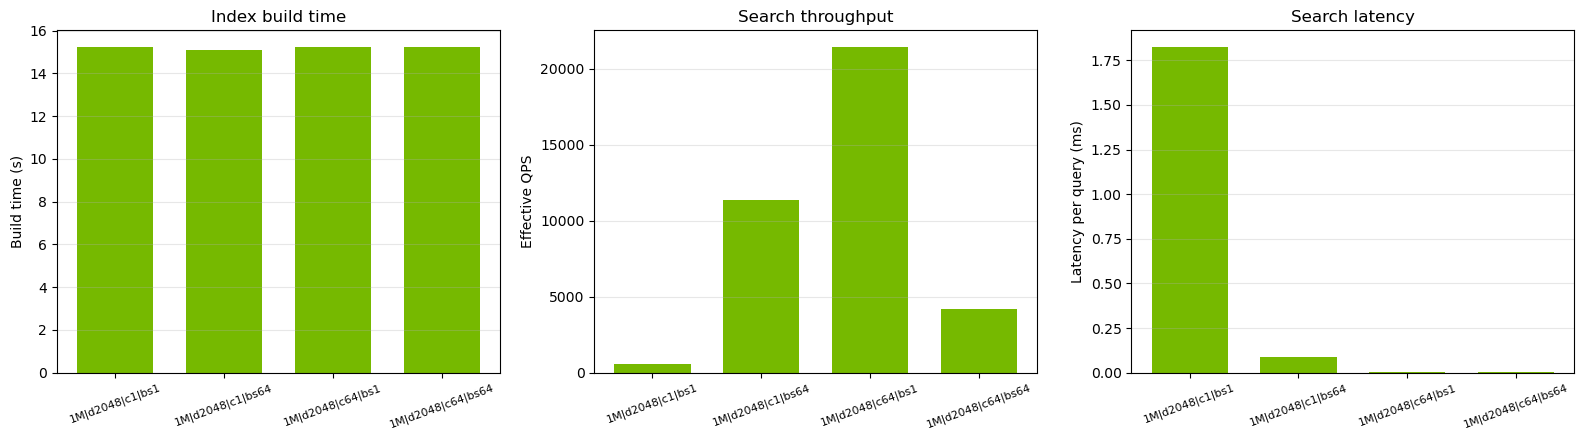

,size,dim,search_c,batch_size,cuvs_build_algo,cuvs_build_s,cuvs_search_wall_s,cuvs_search_qps_effective,cuvs_recall
0,1000000,2048,1,1,ivf_pq,15.2163,18.2670,547.4358,0.9252
1,1000000,2048,1,64,ivf_pq,15.0998,0.8821,11336.4595,0.9281
2,1000000,2048,64,1,ivf_pq,15.2310,0.4663,21446.3413,0.9114
3,1000000,2048,64,64,ivf_pq,15.2465,2.3995,4167.5175,0.9108


In [25]:
import matplotlib.pyplot as plt

NVIDIA_GREEN = "#76b900"
INTEL_BLUE = "#0071c5"
plot_df = df.sort_values(["size", "dim", "search_c", "batch_size"]).reset_index(drop=True)
plot_df["cuvs_latency_ms"] = 1000.0 * plot_df["cuvs_search_wall_s"] / (n_queries * plot_df["search_c"])
has_faiss = "faiss_build_s" in plot_df.columns
if has_faiss:
    plot_df["faiss_latency_ms"] = 1000.0 * plot_df["faiss_search_wall_s"] / n_queries

labels = plot_df.apply(
    lambda r: f"{int(r['size']/1e6)}M|d{int(r['dim'])}|c{int(r['search_c'])}|bs{int(r['batch_size'])}", axis=1
).tolist()
x = np.arange(len(plot_df))
w = 0.4 if has_faiss else 0.7
xc = x - w/2 if has_faiss else x

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, cu_col, fa_col, ylabel, title in [
    (axes[0], "cuvs_build_s", "faiss_build_s", "Build time (s)", "Index build time"),
    (axes[1], "cuvs_search_qps_effective", "faiss_search_qps_effective", "Effective QPS", "Search throughput"),
    (axes[2], "cuvs_latency_ms", "faiss_latency_ms", "Latency per query (ms)", "Search latency"),
]:
    ax.bar(xc, plot_df[cu_col], w, label="cuVS CAGRA", color=NVIDIA_GREEN)
    if has_faiss:
        ax.bar(x + w/2, plot_df[fa_col], w, label="FAISS HNSW", color=INTEL_BLUE)
        ax.legend()
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, fontsize=8)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

cols = ["size", "dim", "search_c", "batch_size", "cuvs_build_algo",
        "cuvs_build_s", "cuvs_search_wall_s", "cuvs_search_qps_effective", "cuvs_recall"]
if has_faiss:
    cols += ["faiss_build_s", "faiss_search_wall_s", "faiss_search_qps_effective", "faiss_recall"]
summary_df = plot_df[cols].round(4)
summary_df.to_csv("index_size_analysis_results.csv", index=False)
summary_df
